A carregar os dados de vendas do limpos_final.xlsm...
A carregar a tabela de CO2_transporte.csv...

Concluído com sucesso! A imagem da matriz pura foi guardada como 'matriz_impacto_co2_pura.png'.


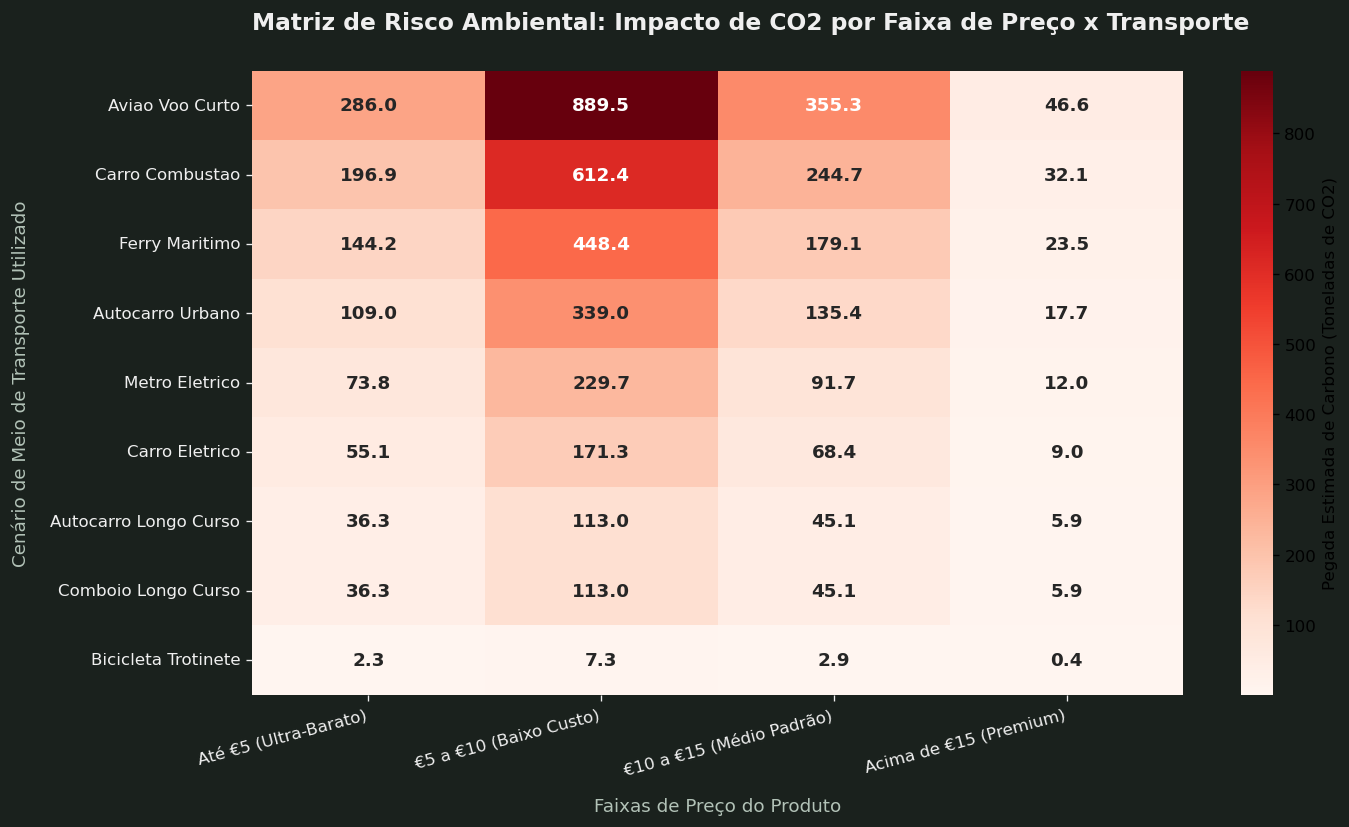

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregamento os dados do teu ficheiro Excel (Vendas)
print("A carregar os dados de vendas do limpos_final.xlsm...")
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    df_vendas = limpos[list(limpos.keys())[0]]
except Exception as e:
    print(f"Erro ao carregar o Excel de vendas: {e}")
    exit()

# 2. Carregamento do novo CSV de CO2 fornecido
print("A carregar a tabela de CO2_transporte.csv...")
try:
    df_co2 = pd.read_csv('../../../Datasets/CO2_transporte.csv')
except Exception as e:
    print(f"Erro ao carregar o CSV de CO2: {e}")
    exit()

# 3. Tratamento dos dados de vendas
df_vendas['price_num'] = pd.to_numeric(df_vendas['price'], errors='coerce')
df_vendas['units_sold_pure'] = pd.to_numeric(df_vendas['units_sold'], errors='coerce')

df_validos = df_vendas[
    (df_vendas['price_num'] > 0) & (df_vendas['units_sold_pure'].notna())
].copy()

# Criar as faixas de preço consistentes
bins = [0, 5, 10, 15, np.inf]
labels = ['Até €5 (Ultra-Barato)', '€5 a €10 (Baixo Custo)', '€10 a €15 (Médio Padrão)', 'Acima de €15 (Premium)']
df_validos['faixa_preco'] = pd.cut(df_validos['price_num'], bins=bins, labels=labels)

# Agrupar volume total de unidades vendidas por faixa de preço
vendas_por_faixa = df_validos.groupby('faixa_preco', observed=False)['units_sold_pure'].sum().reset_index()

# 4. Cruzamento de Matrizes: Calcular o Impacto de CO2 por Faixa de Preço para cada Transporte
matriz_impacto = []

for _, linha_preco in vendas_por_faixa.iterrows():
    faixa = linha_preco['faixa_preco']
    unidades = linha_preco['units_sold_pure']
    
    for _, linha_transporte in df_co2.iterrows():
        meio = linha_transporte['meio_transporte']
        fator_emissao = linha_transporte['emissao_media_g_co2_pkm']
        
        # CO2 Total estimado em Toneladas (T)
        co2_toneladas = (unidades * fator_emissao) / 1_000_000
        
        matriz_impacto.append({
            'Faixa de Preço': faixa,
            'Meio de Transporte': meio.replace('_', ' ').title(),
            'CO2_Toneladas': co2_toneladas
        })

df_matriz = pd.DataFrame(matriz_impacto)

# Pivotar a tabela para criar a estrutura do Heatmap
df_pivot = df_matriz.pivot(index='Meio de Transporte', columns='Faixa de Preço', values='CO2_Toneladas')
df_pivot = df_pivot[labels]
df_pivot = df_pivot.loc[df_pivot.mean(axis=1).sort_values(ascending=False).index]

# 5. Construção do Layout Isolado (Estilo Dark Executivo)
cor_fundo = '#1A211D'
fig, ax_grafico = plt.subplots(figsize=(12, 7), dpi=120)
fig.patch.set_facecolor(cor_fundo)
ax_grafico.set_facecolor(cor_fundo)

# Desenhar o Heatmap focado
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap='Reds', cbar=True,
            ax=ax_grafico, annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={'label': 'Pegada Estimada de Carbono (Toneladas de CO2)'})

# Estilização Completa e Alinhamento
ax_grafico.set_title('Matriz de Risco Ambiental: Impacto de CO2 por Faixa de Preço x Transporte', color='#EFEFEF', fontsize=14, pad=25, weight='bold', loc='left')
ax_grafico.set_ylabel('Cenário de Meio de Transporte Utilizado', color='#B2C2B7', fontsize=11, labelpad=12)
ax_grafico.set_xlabel('Faixas de Preço do Produto', color='#B2C2B7', fontsize=11, labelpad=12)

# Ajuste fino das cores e rotações dos eixos
ax_grafico.tick_params(colors='#EFEFEF', labelsize=10, axis='both')
plt.setp(ax_grafico.get_xticklabels(), rotation=15, ha="right")

# Limpar as bordas do gráfico para o visual ficar profissional
for spine in ['top', 'right', 'left', 'bottom']:
    ax_grafico.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('matriz_impacto_co2_pura.png', facecolor=cor_fundo)
print("\nConcluído com sucesso! A imagem da matriz pura foi guardada como 'matriz_impacto_co2_pura.png'.")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>